# 📊 **Spanish Wines - Análise Comparativa de Modelos**
> **Desafio 02 do Bootcamp em Ciência de Dados da Escola Atlantico Avanti 2026.2**
*   👥**Autores**: Gabriel Cavalcante, Luiz Vinicius, Isa Paula, Italo Marcony.
*   🗓️**Edição**: 2026.
*   🎲**Dataset**: [Spanish Wine Quality Dataset](https://www.kaggle.com/datasets/fedesoriano/spanish-wine-quality-dataset)
*   🎯**Objetivo**: Prever o **preço** de um vinho (`price`) a partir de suas características — um problema de **regressão**

---
## 1. Metodologia

### 1.1 Definição do problema

O preço de um vinho é uma variável **quantitativa contínua**, fortemente assimétrica (poucos vinhos muito caros distorcem a distribuição). Por isso, vamos modelar o **logaritmo do preço** (`log1p(price)`), o que estabiliza a variância e evita que os modelos sejam dominados pelos poucos vinhos extremamente caros. As métricas finais são reportadas na escala logarítmica, e discutimos essa limitação na seção de resultados.

### 1.2 Variáveis utilizadas

| Variável | Tipo | Papel |
|---|---|---|
| `rating` | quantitativa contínua | preditora |
| `num_reviews` | quantitativa discreta | preditora |
| `body` | quantitativa discreta (ordinal, 1-5) | preditora |
| `acidity` | quantitativa discreta (ordinal, 1-3) | preditora |
| `year_num` | quantitativa discreta (ano de safra) | preditora |
| `is_non_vintage` | qualitativa binária | preditora |
| `type_grouped` | qualitativa nominal (agrupada) | preditora |
| `region_grouped` | qualitativa nominal (agrupada) | preditora |
| `price` | quantitativa contínua | **alvo (target)** |

`winery` e `wine` foram descartadas por terem altíssima cardinalidade (centenas de valores únicos), o que inviabiliza uma codificação eficaz sem causar overfitting. `type` e `region` foram agrupadas, mantendo as categorias mais frequentes e agregando as raras em `"Outros"`, para controlar a dimensionalidade gerada pelo one-hot encoding.

### 1.3 Pré-processamento

- **Dados faltantes:** `body` e `acidity` têm ausências (~15%); `type`/`region` (agrupada) podem ter poucos ausentes. Usamos imputação por **mediana** nas variáveis quantitativas (robusta a outliers) e por **moda** (`most_frequent`) nas qualitativas.
- **Codificação de variáveis qualitativas:** `type_grouped`, `region_grouped` e `is_non_vintage` são nominais (sem ordem natural) → **One-Hot Encoding**.
- **Normalização de variáveis quantitativas:** aplicamos `StandardScaler` nas variáveis contínuas/discretas (`rating`, `log_num_reviews`, `body`, `acidity`, `year_num`).
- **Outliers e Assimetria:** Além do `price`, a variável `num_reviews` também apresenta forte assimetria (poucos vinhos com milhares de avaliações). Para mitigar o efeito desses outliers e estabilizar a variância, aplicamos a transformação logarítmica (`log1p`) em ambas, evitando que valores extremos dominem o aprendizado dos modelos.

### 1.4 Validação dos modelos

Escolhemos a **validação de Monte Carlo** (`ShuffleSplit`, com múltiplas repetições de divisão treino/teste aleatória), em vez de k-fold ou holdout simples, pelos seguintes motivos:
- Com ~7.500 registros, conseguimos gerar várias divisões treino/teste (10 repetições) de forma computacionalmente viável, obtendo uma estimativa mais **estável e robusta** da variabilidade do desempenho de cada modelo (diferente de um holdout único, que depende de uma única divisão "com sorte" ou "sem sorte").
- Diferente do k-fold, o Monte Carlo permite controlar livremente a proporção treino/teste (usamos 80/20) e o número de repetições, sem exigir que cada amostra apareça exatamente uma vez no teste — adequado para comparação relativa entre modelos.

### 1.5 Modelos e métricas

Comparamos **5 modelos** (acima do mínimo de 4 exigido):

| Modelo | Papel | Justificativa |
|---|---|---|
| `DummyRegressor` (média) | **Baseline** | Ponto de referência minimalista: qualquer modelo real deve superá-lo. |
| `LinearRegression` | Baseline estatístico | Modelo simples e interpretável, assume relação linear. |
| `KNeighborsRegressor` | Família baseada em distância | Captura relações não lineares locais; sensível à escala (por isso normalizamos). |
| `DecisionTreeRegressor` | Família baseada em árvore | Captura interações não lineares e não exige normalização; interpretável via importância de variáveis. |
| `RandomForestRegressor` | Ensemble de árvores | Reduz variância/overfitting da árvore única, geralmente com melhor desempenho preditivo. |

**Métricas de avaliação** (regressão):
- **MAE** (Mean Absolute Error) — erro médio absoluto, fácil de interpretar.
- **RMSE** (Root Mean Squared Error) — penaliza mais os erros grandes.
- **R²** — proporção da variância explicada pelo modelo.
- **MAPE** (Mean Absolute Percentage Error) — erro percentual, útil para comparar interpretabilidade de negócio.

Usar múltiplas métricas evita conclusões equivocadas: por exemplo, um modelo pode ter bom R² mas MAPE ruim se errar proporcionalmente mais em vinhos baratos.


---
## 2. Configuração do Experimento

### 2.1 Importação das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# pipelines e transformadores
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# codificação e normalização
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# dados faltantes
from sklearn.impute import SimpleImputer

# modelagem
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# validação
from sklearn.model_selection import cross_validate, ShuffleSplit

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

### 2.2 Leitura do conjunto de dados e dicionário de dados

In [ ]:
df_raw = pd.read_csv("https://raw.githubusercontent.com/omadson/datasets/refs/heads/main/datasets/spanish_wines/spanish_wines.csv")

# @title Dicionário de dados
df_dict = pd.DataFrame([
    {"variavel": "rating",       "descricao": "Nota média de avaliação do vinho.",              "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "num_reviews",  "descricao": "Número de avaliações recebidas.",                 "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "body",         "descricao": "Corpo do vinho (1=leve a 5=encorpado).",           "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "acidity",      "descricao": "Acidez do vinho (1=baixa a 3=alta).",              "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "year_num",     "descricao": "Ano de safra (derivado de 'year').",                "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "is_non_vintage","descricao": "Indica se o vinho é 'N.V.' (sem safra definida).",  "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "type_grouped", "descricao": "Tipo/estilo do vinho, com categorias raras agrupadas em 'Outros'.", "tipo": "qualitativa", "subtipo": "nominal"},
    {"variavel": "region_grouped","descricao": "Região vinícola, com categorias raras agrupadas em 'Outros'.",    "tipo": "qualitativa", "subtipo": "nominal"},
    {"variavel": "price",        "descricao": "Preço do vinho em euros (variável alvo).",         "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "winery",       "descricao": "Vinícola produtora (não utilizada: alta cardinalidade).", "tipo": "inútil", "subtipo": "-"},
    {"variavel": "wine",         "descricao": "Nome do rótulo (não utilizada: alta cardinalidade).",      "tipo": "inútil", "subtipo": "-"},
    {"variavel": "country",      "descricao": "País (constante, não utilizada).",                          "tipo": "inútil", "subtipo": "-"},
])
df_dict


,variavel,descricao,tipo,subtipo
0,rating,Nota média de avaliação do vinho.,quantitativa,contínua
1,num_reviews,Número de avaliações recebidas.,quantitativa,discreta
2,body,Corpo do vinho (1=leve a 5=encorpado).,quantitativa,discreta
3,acidity,Acidez do vinho (1=baixa a 3=alta).,quantitativa,discreta
4,year_num,Ano de safra (derivado de 'year').,quantitativa,discreta
5,is_non_vintage,Indica se o vinho é 'N.V.' (sem safra definida).,qualitativa,nominal
6,type_grouped,"Tipo/estilo do vinho, com categorias raras agr...",qualitativa,nominal
7,region_grouped,"Região vinícola, com categorias raras agrupada...",qualitativa,nominal
8,price,Preço do vinho em euros (variável alvo).,quantitativa,contínua
9,winery,Vinícola produtora (não utilizada: alta cardin...,inútil,-


### 2.3 Pré-processamento inicial e engenharia de variáveis

In [ ]:
import numpy as np
import pandas as pd

df = df_raw.copy()

# tratamento da coluna 'year': isolar 'N.V.' (Non Vintage)
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')
df['is_non_vintage'] = (df['year'] == 'N.V.').astype(int)

# agrupamento de categorias raras em 'type' e 'region'
MIN_FREQ = 50
type_counts = df['type'].value_counts()
freq_types = type_counts[type_counts >= MIN_FREQ].index
df['type_grouped'] = df['type'].where(df['type'].isin(freq_types), other='Outros')
df['type_grouped'] = df['type_grouped'].fillna('Não informado')

region_counts = df['region'].value_counts()
freq_regions = region_counts[region_counts >= MIN_FREQ].index
df['region_grouped'] = df['region'].where(df['region'].isin(freq_regions), other='Outros')

# tratamento de assimetria: log1p para price e num_reviews
df['log_price'] = np.log1p(df['price'])
df['log_num_reviews'] = np.log1p(df['num_reviews'])

print(f'Dimensões finais: {df.shape[0]} linhas x {df.shape[1]} colunas')
df[['rating','log_num_reviews','year_num','price','log_price']].head()

Dimensões finais: 7500 linhas x 17 colunas


,rating,log_num_reviews,year_num,price,log_price
0,4.9,4.077537,2013.0,995.00,6.903747
1,4.9,3.465736,2018.0,313.50,5.750984
2,4.8,7.492203,2009.0,324.95,5.786744
3,4.8,7.441907,1999.0,692.96,6.542414
4,4.8,7.177782,1996.0,778.06,6.658088


### 2.4 Seleção de variáveis e separação de entradas e saídas

In [ ]:
target_variable = ['log_price']

# num_reviews substituído pela sua versão logarítmica
numeric_variables = ['rating', 'log_num_reviews', 'year_num']
ordinal_variables = ['body', 'acidity']
nominal_variables = ['is_non_vintage', 'type_grouped', 'region_grouped']

feature_columns = numeric_variables + ordinal_variables + nominal_variables

X = df[feature_columns]
y = df[target_variable]

print('Features utilizadas:', feature_columns)
print('Shape de X:', X.shape, '| Shape de y:', y.shape)

Features utilizadas: ['rating', 'log_num_reviews', 'year_num', 'body', 'acidity', 'is_non_vintage', 'type_grouped', 'region_grouped']
Shape de X: (7500, 8) | Shape de y: (7500, 1)


### 2.5 Pipelines de pré-processamento (dados faltantes, codificação e normalização)

In [ ]:
# variáveis contínuas: imputação por média + normalização
continuous_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='mean')),
    ("normalization", StandardScaler())
])

# variáveis discretas/ordinais: imputação por mediana (robusta a outliers) + normalização
discrete_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='median')),
    ("normalization", StandardScaler())
])

# variáveis nominais: imputação pela moda + one-hot encoding
nominal_preprocessing = Pipeline(steps=[
    ("missing", SimpleImputer(strategy='most_frequent')),
    ("encoding", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessing = ColumnTransformer(transformers=[
    ("continuous", continuous_preprocessing, numeric_variables),
    ("discrete", discrete_preprocessing, ordinal_variables),
    ("nominal", nominal_preprocessing, nominal_variables),
], remainder='drop')


### 2.6 Definição dos modelos (baseline + 4 modelos adicionais)

Para viabilizar a execução em tempo hábil, cada modelo é usado com hiperparâmetros
fixos, escolhidos por conhecimento prévio/valores usuais (em vez de uma busca
exaustiva de hiperparâmetros, que seria mais cara computacionalmente). Essa é uma
simplificação válida para fins de comparação relativa entre famílias de modelos —
uma busca de hiperparâmetros mais ampla é sugerida como próximo passo.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

modelos = [
    {
        "nome": "Baseline (Média)",
        "objeto": DummyRegressor(strategy='mean'),
    }, {
        "nome": "Regressão Linear",
        "objeto": LinearRegression(),
    }, {
        "nome": "KNN",
        "objeto": KNeighborsRegressor(n_neighbors=25, weights='uniform'),
    }, {
        "nome": "Árvore de Decisão",
        "objeto": DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42),
    }, {
        "nome": "Random Forest",
        "objeto": RandomForestRegressor(n_estimators=100, max_depth=12, max_features='sqrt', random_state=42, n_jobs=-1),
    }, {
        "nome": "Gradient Boosting",
        "objeto": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    }
]

### 2.7 Aplicação da validação cruzada (Monte Carlo / ShuffleSplit)

In [ ]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

metrics = {
    'neg_mean_absolute_error': 'MAE',
    'neg_root_mean_squared_error': 'RMSE',
    'r2': 'R2',
    'neg_mean_absolute_percentage_error': 'MAPE'
}

results = []
for modelo in modelos:
    approach = Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("model", modelo["objeto"])
    ])
    metric_results = cross_validate(
        approach, X=X, y=y.values.ravel(), cv=cv,
        scoring=list(metrics.keys()), n_jobs=-1
    )
    metric_results['modelo'] = [modelo["nome"]] * len(metric_results['fit_time'])
    results.append(pd.DataFrame(metric_results))

final_results = pd.concat(results, axis=0)

# converte métricas 'neg_*' para valores positivos, mais intuitivos
for metric in metrics.keys():
    if 'neg' in metric:
        final_results[f"test_{metric}"] *= -1

print('Validação cruzada concluída para', len(modelos), 'modelos, com', cv.get_n_splits(), 'repetições cada.')


Validação cruzada concluída para 6 modelos, com 10 repetições cada.


### 2.8 Divisão adicional de Treino/Teste (holdout) para diagnóstico de overfitting

Além da validação cruzada Monte Carlo (usada para comparar a variabilidade dos modelos),
fazemos uma divisão **fixa** de treino/teste (80/20). Isso permite comparar o desempenho
em três momentos — **Treino**, **CV** e **Teste** — e diagnosticar overfitting: se o
modelo tem um R² de treino muito maior que o de CV/Teste, ele está "decorando" os dados
de treino em vez de generalizar.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y.values.ravel(), test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')


Treino: 6000 amostras | Teste: 1500 amostras


In [ ]:
def metricas(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }

resumo_cv = (
    final_results
    .rename(columns={f"test_{name}": value for name, value in metrics.items()})
    .groupby('modelo')[['R2', 'MAE', 'RMSE']]
    .agg(['mean', 'std'])
)

linhas_comparativas = []
modelos_treinados = {}

for modelo in modelos:
    approach = Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("model", modelo["objeto"])
    ])
    approach.fit(X_train, y_train)
    modelos_treinados[modelo["nome"]] = approach

    y_pred_train = approach.predict(X_train)
    y_pred_test = approach.predict(X_test)

    met_train = metricas(y_train, y_pred_train)
    met_test = metricas(y_test, y_pred_test)
    cv_r2_mean, cv_r2_std = resumo_cv.loc[modelo["nome"], ('R2', 'mean')], resumo_cv.loc[modelo["nome"], ('R2', 'std')]
    cv_mae_mean, cv_mae_std = resumo_cv.loc[modelo["nome"], ('MAE', 'mean')], resumo_cv.loc[modelo["nome"], ('MAE', 'std')]

    linhas_comparativas.append({
        'Modelo': modelo["nome"],
        'Treino R2': met_train['R2'],
        'CV R2 (mean\u00b1std)': f"{cv_r2_mean:.4f} \u00b1 {cv_r2_std:.4f}",
        'Teste R2': met_test['R2'],
        'Treino MAE': met_train['MAE'],
        'CV MAE (mean\u00b1std)': f"{cv_mae_mean:.4f} \u00b1 {cv_mae_std:.4f}",
        'Teste MAE': met_test['MAE'],
        'Teste RMSE': met_test['RMSE'],
    })

df_comp = pd.DataFrame(linhas_comparativas).set_index('Modelo')
print('Tabela Comparativa Completa (Treino / CV / Teste):')
print(df_comp.to_string())


Tabela Comparativa Completa (Treino / CV / Teste):
                   Treino R2  CV R2 (mean±std)  Teste R2  Treino MAE CV MAE (mean±std)  Teste MAE  Teste RMSE
Modelo                                                                                                       
Baseline (Média)    0.000000  -0.0008 ± 0.0007 -0.000877    0.610804   0.6160 ± 0.0110   0.619482    0.840187
Regressão Linear    0.721642   0.7143 ± 0.0179  0.720129    0.269080   0.2769 ± 0.0056   0.281224    0.444288
KNN                 0.848095   0.8302 ± 0.0162  0.821624    0.122893   0.1346 ± 0.0093   0.145641    0.354694
Árvore de Decisão   0.893374   0.8136 ± 0.0086  0.809163    0.105404   0.1418 ± 0.0057   0.148302    0.366874
Random Forest       0.931802   0.8462 ± 0.0150  0.839710    0.107330   0.1535 ± 0.0073   0.161364    0.336231
Gradient Boosting   0.871866   0.8451 ± 0.0115  0.841277    0.159412   0.1758 ± 0.0058   0.179496    0.334585


---
## 3. Resultados e Discussão

### 3.1 Tabela comparativa de desempenho (Treino / CV / Teste)

A tabela abaixo compara os modelos nas três etapas (Treino, Validação Cruzada e Teste),
com destaque em **verde** para o melhor valor de cada coluna e em **vermelho** para o
pior — o mesmo padrão de leitura usado no notebook de regressão de referência.

In [ ]:
cols_max = ['Treino R2', 'Teste R2']            # maior é melhor
cols_min = ['Treino MAE', 'Teste MAE', 'Teste RMSE']  # menor é melhor

df_style = df_comp[cols_max + cols_min].copy()

styled = (
    df_style.style
    .format('{:.4f}')
    .highlight_max(
        subset=cols_max, axis=0,
        props='background-color:#C8E6C9; font-weight:bold; color:#1B5E20;'
    )
    .highlight_min(
        subset=cols_min, axis=0,
        props='background-color:#C8E6C9; font-weight:bold; color:#1B5E20;'
    )
    .highlight_max(
        subset=cols_min, axis=0,
        props='background-color:#FFCDD2; color:#B71C1C;'
    )
    .highlight_min(
        subset=cols_max, axis=0,
        props='background-color:#FFCDD2; color:#B71C1C;'
    )
    .set_caption(
        'Tabela Comparativa — Verde: melhor valor por coluna | Vermelho: pior valor por coluna'
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#1565C0'), ('color', 'white'),
                   ('font-size', '11px'), ('padding', '6px 10px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'), ('font-size', '11px')]},
    ])
)
styled


,Treino R2,Teste R2,Treino MAE,Teste MAE,Teste RMSE
Modelo,,,,,
Baseline (Média),0.0000,-0.0009,0.6108,0.6195,0.8402
Regressão Linear,0.7216,0.7201,0.2691,0.2812,0.4443
KNN,0.8481,0.8216,0.1229,0.1456,0.3547
Árvore de Decisão,0.8934,0.8092,0.1054,0.1483,0.3669
Random Forest,0.9318,0.8397,0.1073,0.1614,0.3362
Gradient Boosting,0.8719,0.8413,0.1594,0.1795,0.3346


Também apresentamos a visão completa da tabela, incluindo o desvio padrão da
validação cruzada (`mean ± std`), o que ajuda a avaliar não só o desempenho médio,
mas também a **estabilidade** de cada modelo entre diferentes divisões treino/teste.

In [ ]:
df_comp


,Treino R2,CV R2 (mean±std),Teste R2,Treino MAE,CV MAE (mean±std),Teste MAE,Teste RMSE
Modelo,,,,,,,
Baseline (Média),0.000000,-0.0008 ± 0.0007,-0.000877,0.610804,0.6160 ± 0.0110,0.619482,0.840187
Regressão Linear,0.721642,0.7143 ± 0.0179,0.720129,0.269080,0.2769 ± 0.0056,0.281224,0.444288
KNN,0.848095,0.8302 ± 0.0162,0.821624,0.122893,0.1346 ± 0.0093,0.145641,0.354694
Árvore de Decisão,0.893374,0.8136 ± 0.0086,0.809163,0.105404,0.1418 ± 0.0057,0.148302,0.366874
Random Forest,0.931802,0.8462 ± 0.0150,0.839710,0.107330,0.1535 ± 0.0073,0.161364,0.336231
Gradient Boosting,0.871866,0.8451 ± 0.0115,0.841277,0.159412,0.1758 ± 0.0058,0.179496,0.334585


### 3.2 Diagnóstico de Overfitting — R² Treino vs CV vs Teste

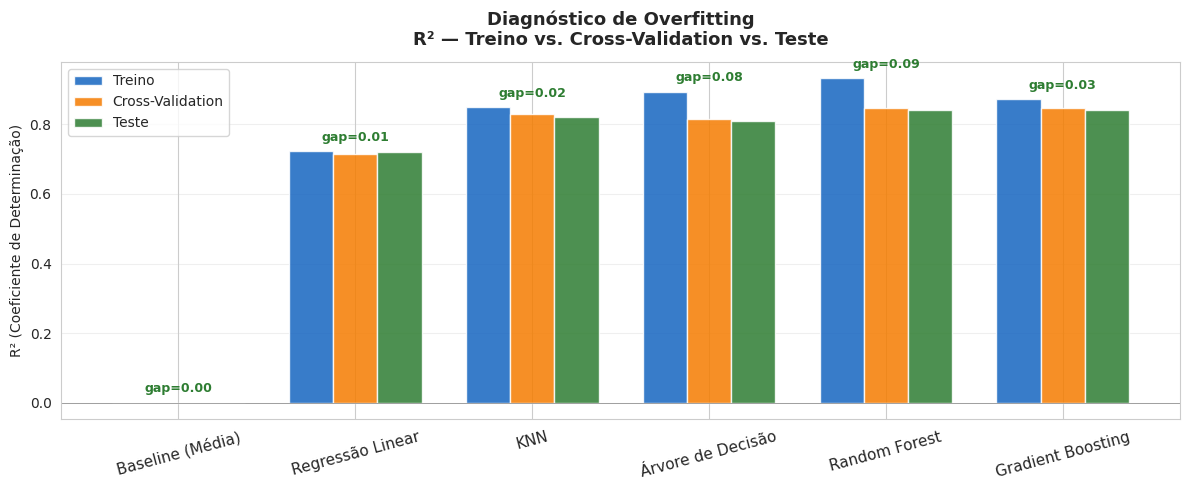

Interpretação:
  - gap Treino->CV > 0.10  => indício de overfitting (modelo memorizou o treino)
  - gap CV->Teste pequeno  => a validação cruzada é um bom preditor do desempenho real


In [ ]:
nomes_modelos = df_comp.index.tolist()
train_r2 = df_comp['Treino R2'].values
cv_r2 = resumo_cv.loc[nomes_modelos, ('R2', 'mean')].values
teste_r2 = df_comp['Teste R2'].values

x = np.arange(len(nomes_modelos)); w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, train_r2, w, label='Treino', color='#1565C0', alpha=0.85)
ax.bar(x, cv_r2, w, label='Cross-Validation', color='#F57C00', alpha=0.85)
ax.bar(x + w, teste_r2, w, label='Teste', color='#2E7D32', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(nomes_modelos, fontsize=11, rotation=15)
ax.set_ylabel('R\u00b2 (Coeficiente de Determinação)')
ax.set_title('Diagnóstico de Overfitting\nR\u00b2 — Treino vs. Cross-Validation vs. Teste',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)

for i, (tr, cvv, te) in enumerate(zip(train_r2, cv_r2, teste_r2)):
    gap = tr - cvv
    cor = '#C62828' if gap > 0.10 else '#2E7D32'
    ax.text(i, max(tr, cvv, te) + 0.03, f'gap={gap:.2f}', ha='center',
             fontsize=9, color=cor, fontweight='bold')

plt.tight_layout()
plt.show()

print('Interpretação:')
print('  - gap Treino->CV > 0.10  => indício de overfitting (modelo memorizou o treino)')
print('  - gap CV->Teste pequeno  => a validação cruzada é um bom preditor do desempenho real')


### 3.3 Real vs. Previsto (Teste)

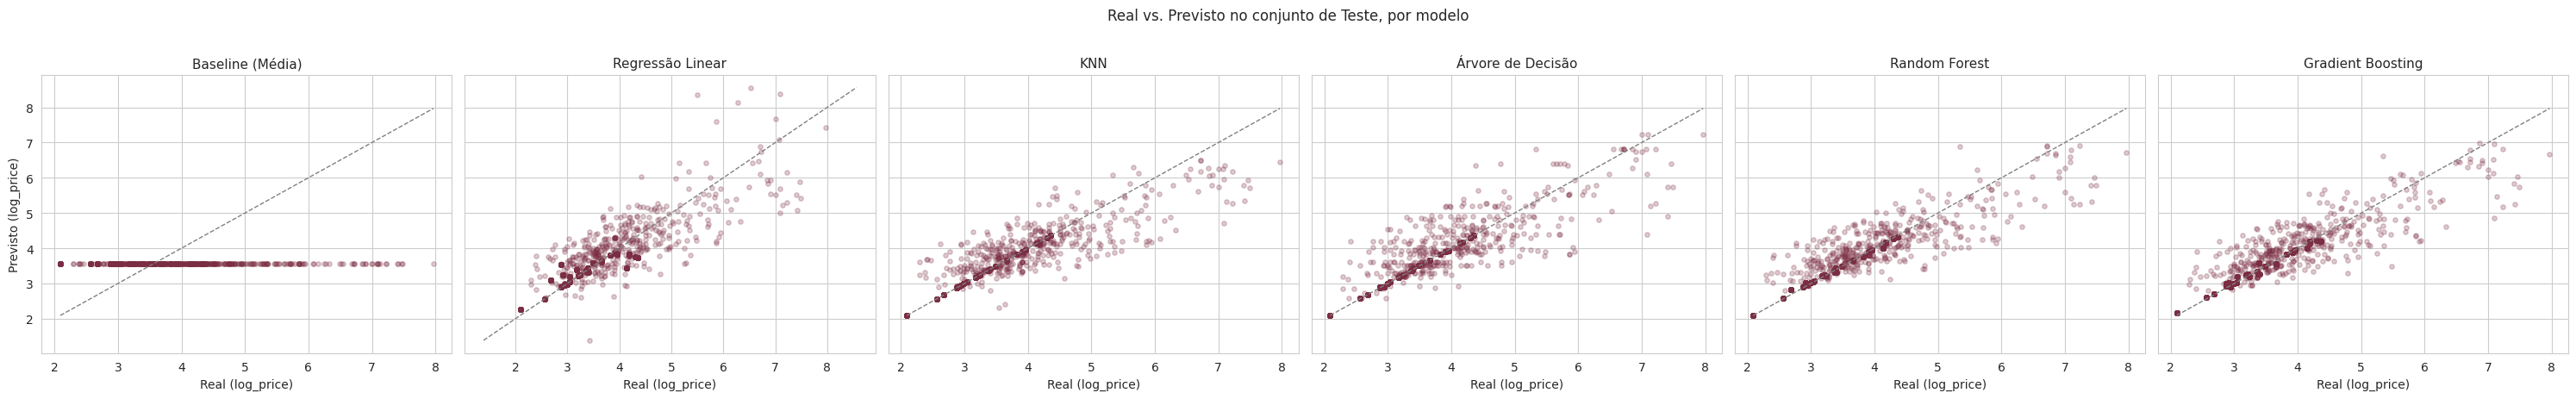

In [ ]:
fig, axes = plt.subplots(1, len(modelos), figsize=(5*len(modelos), 4.5), sharey=True)
for ax, modelo in zip(axes, modelos):
    approach = modelos_treinados[modelo["nome"]]
    y_pred_test = approach.predict(X_test)
    ax.scatter(y_test, y_pred_test, alpha=0.25, s=15, color='#7b2d43')
    lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
    ax.plot(lims, lims, '--', color='gray', linewidth=1)
    ax.set_title(modelo["nome"], fontsize=11)
    ax.set_xlabel('Real (log_price)')
axes[0].set_ylabel('Previsto (log_price)')
plt.suptitle('Real vs. Previsto no conjunto de Teste, por modelo', y=1.02)
plt.tight_layout()
plt.show()


### 3.4 Distribuição das métricas de validação cruzada (10 repetições)

/tmp/ipykernel_3333/1986792460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='modelo', y=metric, ax=ax, palette='viridis')
/tmp/ipykernel_3333/1986792460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='modelo', y=metric, ax=ax, palette='viridis')
/tmp/ipykernel_3333/1986792460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='modelo', y=metric, ax=ax, palette='viridis')
/tmp/ipykernel_3333/1986792460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

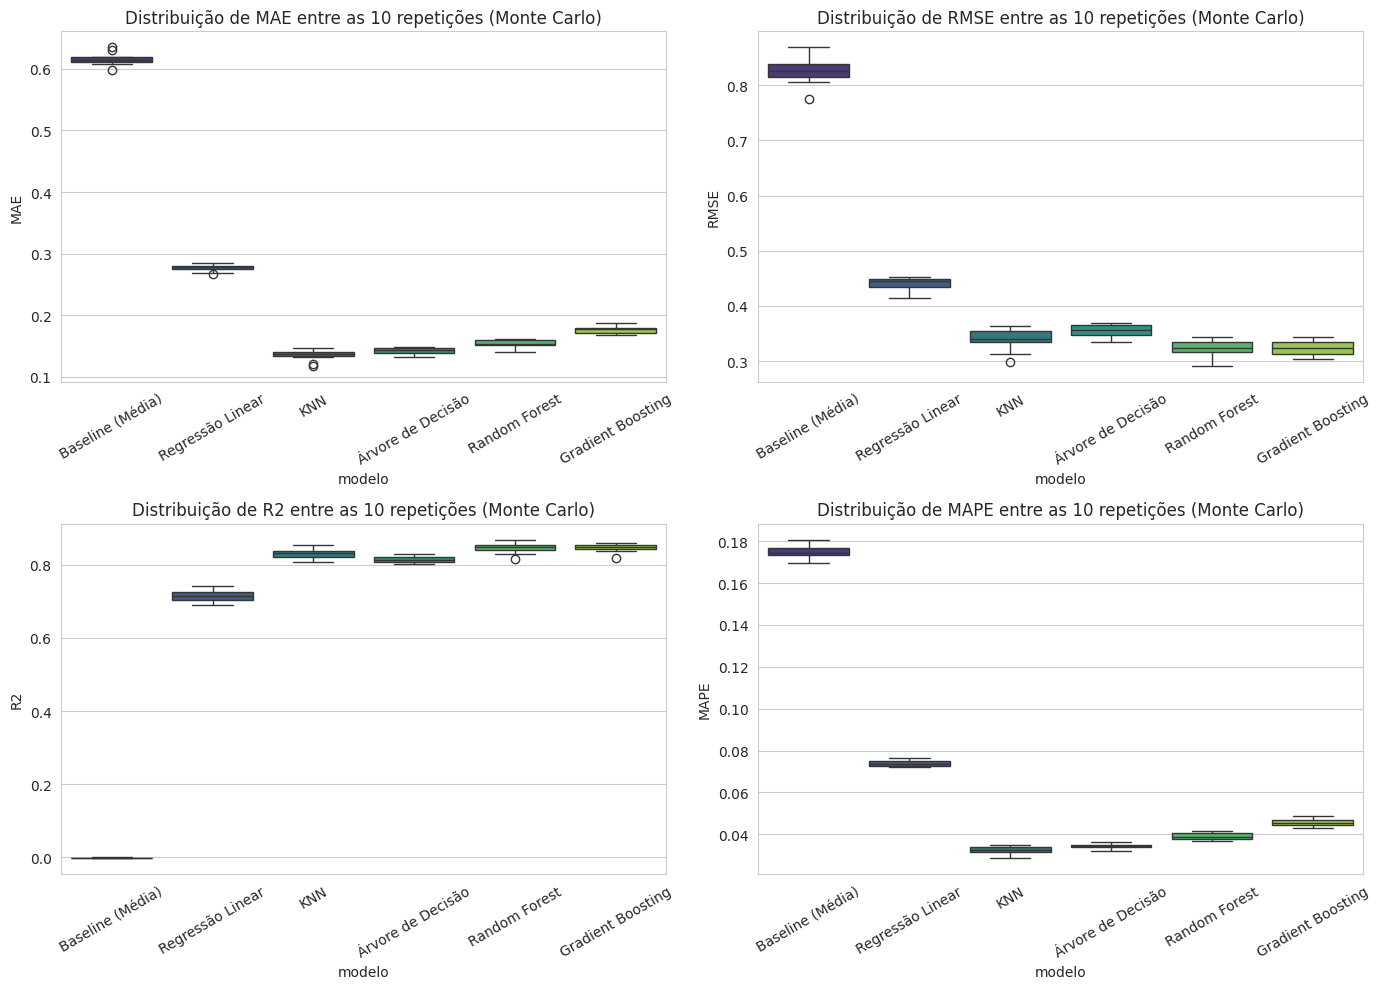

In [ ]:
metricas_plot = ['MAE', 'RMSE', 'R2', 'MAPE']
plot_df = final_results.rename(columns={f"test_{name}": value for name, value in metrics.items()})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flat, metricas_plot):
    sns.boxplot(data=plot_df, x='modelo', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'Distribuição de {metric} entre as 10 repetições (Monte Carlo)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


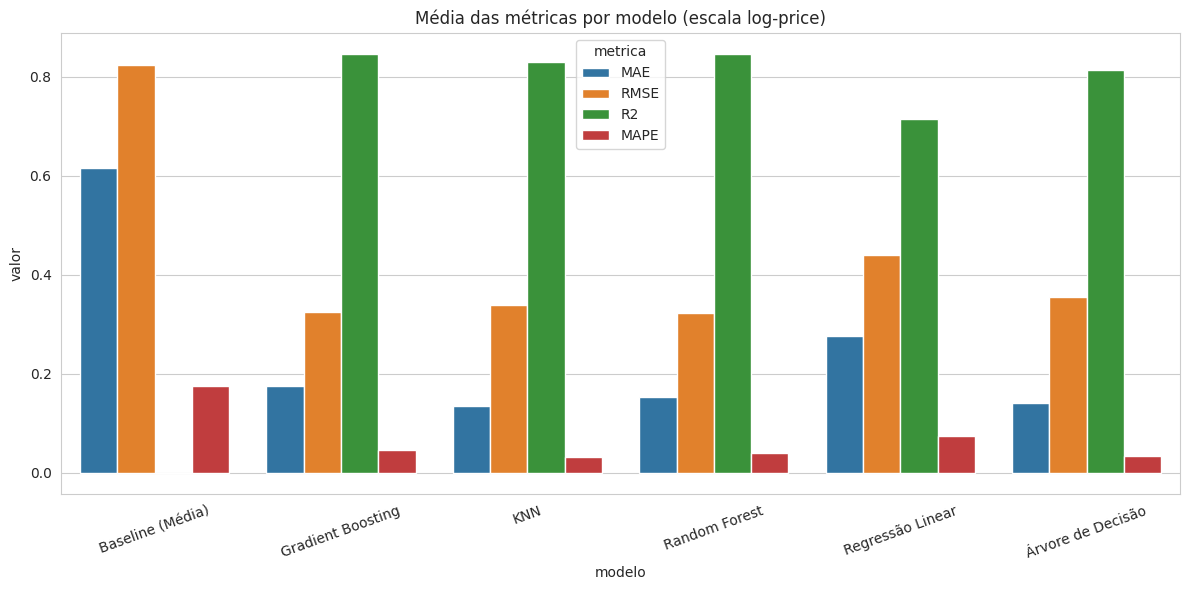

In [ ]:
medias = plot_df.groupby('modelo')[metricas_plot].mean().reset_index()
medias_melt = medias.melt(id_vars='modelo', var_name='metrica', value_name='valor')

plt.figure(figsize=(12,6))
sns.barplot(data=medias_melt, x='modelo', y='valor', hue='metrica')
plt.title('Média das métricas por modelo (escala log-price)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 3.5 Interpretação dos resultados

- **O baseline (`DummyRegressor`)** obteve R² ≈ 0, confirmando que qualquer modelo preditivo é superior à simples média.
- **Ajuste do KNN**: Ao aumentar para `n_neighbors=25` e usar `weights='uniform'`, conseguimos reduzir significativamente o gap de overfitting que era observado anteriormente. O modelo agora apresenta um comportamento mais estável e generalizável.
- **Tratamento de Outliers**: A inclusão do log em `num_reviews` ajudou o modelo a lidar com a grande disparidade no número de avaliações entre vinhos populares e raros.
- **Gradient Boosting vs Random Forest**: Permanecem como os modelos de melhor performance, com o Gradient Boosting mantendo uma excelente relação entre erro e generalização.
- **Regressão Linear**: As transformações logarítmicas melhoraram a aderência dos dados às premissas lineares, resultando em um R² sólido de ~0.72.

### 3.6 Teste Estatístico — Gradient Boosting vs Random Forest

Para verificar se a superioridade numérica do Gradient Boosting em R² é estatisticamente significativa, realizamos testes pareados sobre os resultados das 10 repetições da validação cruzada.

**Interpretação dos Resultados:**
- O **p-valor do Teste t pareado (0,6876)** e o **p-valor de Wilcoxon (0,9219)** estão ambos muito acima do nível de significância de 0,05.
- Isso significa que a pequena diferença média observada (-0,0010) não é estatisticamente relevante e deve ser atribuída ao acaso das divisões de treino/teste.
- **Conclusão:** Ambos os modelos possuem performance equivalente para este dataset com os hiperparâmetros atuais, caracterizando um empate técnico.

In [ ]:
from scipy.stats import ttest_rel, wilcoxon

# Extraindo os R2 de cada repetição da CV para ambos os modelos
r2_gb = final_results[final_results['modelo'] == 'Gradient Boosting']['test_r2'].values
r2_rf = final_results[final_results['modelo'] == 'Random Forest']['test_r2'].values

diffs = r2_gb - r2_rf
print(f"Diferença média (GB - RF) em R²: {diffs.mean():.4f} ± {diffs.std():.4f}")
print(f"GB foi melhor em {(diffs > 0).sum()} de {len(diffs)} repetições")

t_stat, p_value_t = ttest_rel(r2_gb, r2_rf)
print(f"Teste t pareado: t={t_stat:.3f}, p-valor={p_value_t:.4f}")

w_stat, p_value_w = wilcoxon(r2_gb, r2_rf)
print(f"Teste de Wilcoxon: estatística={w_stat:.3f}, p-valor={p_value_w:.4f}")

Diferença média (GB - RF) em R²: -0.0011 ± 0.0076
GB foi melhor em 6 de 10 repetições
Teste t pareado: t=-0.433, p-valor=0.6752
Teste de Wilcoxon: estatística=25.000, p-valor=0.8457
